# Influence des infrastructures et aménagements routiers
# -> Peut t'on predire la severite d'un accident

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
    .master("local[*]")\
    .appName("Accident")\
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

your 131072x1 screen size is bogus. expect trouble
25/06/19 11:45:26 WARN Utils: Your hostname, DESKTOP-NHT3FJU resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/06/19 11:45:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/19 11:45:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/06/19 11:45:28 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
df = spark.read.parquet("../../data/processed_accidents_v2.parquet/")
df = df.filter(df["Severity"].isin([1, 2, 3, 4]))
df.show(5, truncate=False)

+--------+-------------------+-------------------+---------+-----------+------------------+---------------+-----------+-----+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|Severity|Start_Time         |End_Time           |Start_Lat|Start_Lng  |Distance(mi)      |City           |County     |State|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Amenity|Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station|Stop|Traffic_Calming|Traffic_Signal|Turning_Loop|Sunrise_Sunset|Civil_Twilight|Nautical_Twilight|Astronomical_Twilight|
+--------+-------------------+-------------------+---------+-----------+----------------

## Data Preprocess

On ne garde que les colonnes qui semblent importante pour la prediction de la severite d'un accident

In [3]:
columns_to_keep = [
    "Severity",

    'Start_Lat', 'Start_Lng', 'Distance(mi)',

    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',

    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop',

    'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight',

    'Weather_Condition', 'Wind_Direction',
    'State'
]

df = df.select(columns_to_keep)

On plot la matrice de correlation avec toutes les colonnes selectionne juste avant pour s'assurer une bonne qualite des features

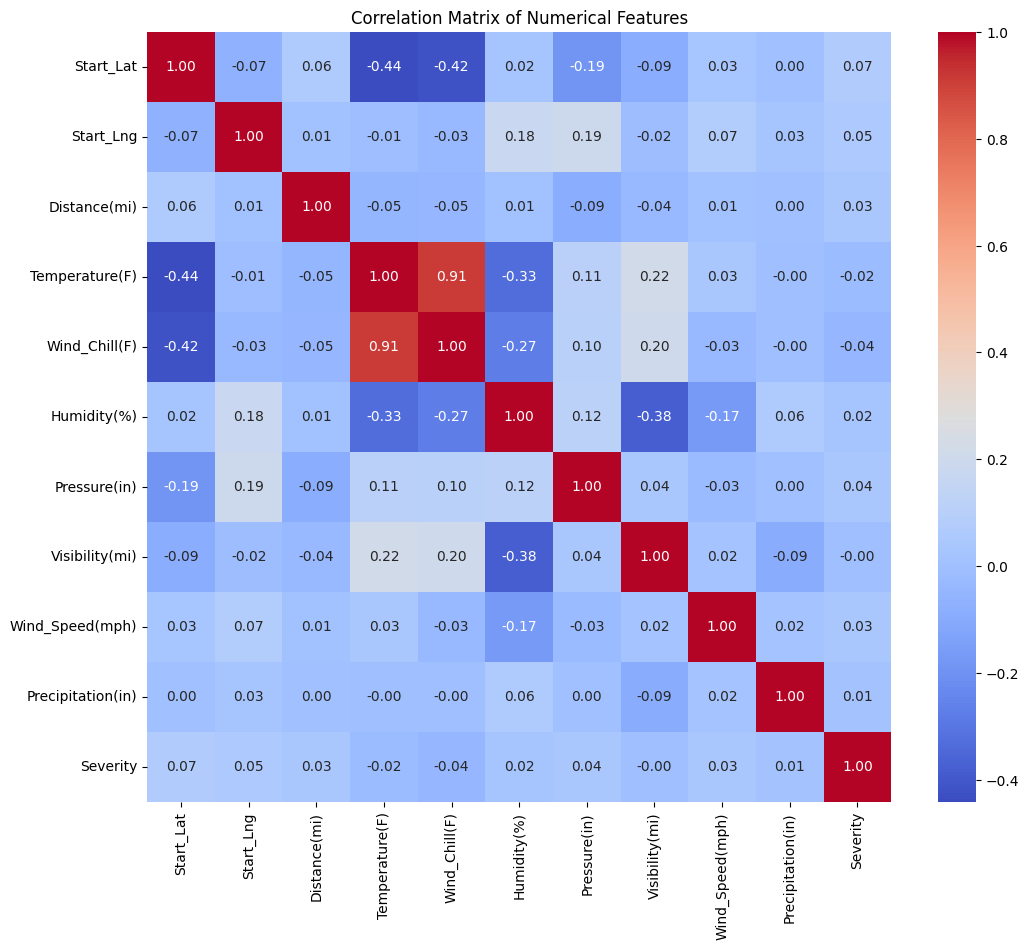

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

numerical_features = [
    'Start_Lat', 'Start_Lng', 'Distance(mi)',
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Severity'
]

sample_df = df.select(numerical_features).sample(withReplacement=False, fraction=0.1, seed=42)
pandas_df = sample_df.toPandas()

plt.figure(figsize=(12, 10))
sns.heatmap(pandas_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


On remarque que les colonnes `Wind_Chill(F)` et `Temperature(F)` sont tres correlees entres elles, alors on peut en supprimer une des deux

In [4]:
df = df.drop("Wind_Chill(F)")

remplacer State par des variables plus explicables

In [5]:
state_to_region = {
    'AZ': 'West', 'NV': 'West', 'CA': 'West', 'OR': 'West', 'ID': 'West', 'MT': 'West',
    'MN': 'Midwest', 'MI': 'Midwest', 'WI': 'Midwest', 'NE': 'Midwest',
    'NJ': 'Northeast', 'CT': 'Northeast', 'RI': 'Northeast', 'NH': 'Northeast',
    'SC': 'South', 'KY': 'South', 'VA': 'South', 'LA': 'South', 'DC': 'South',
    'WY': 'West'
}

from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

@udf(returnType=StringType())
def map_region(state):
    return state_to_region.get(state, 'Other')

df = df.withColumn("Region", map_region(df.State))

In [6]:
df = df.drop("State")

Pour le choix du model final, on va utiliser un subset du dataframe pour eviter des entrainements trop long lors du choix du model

In [7]:
df_sample = df.sample(fraction=0.1, seed=42)

On fait un split `80/20`

In [8]:
train_data_sample, test_data_sample = df_sample.randomSplit([0.8, 0.2], seed=42)
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

In [9]:
train_data_sample.write.mode("overwrite").parquet("train_data_sample.parquet")
test_data_sample.write.mode("overwrite").parquet("test_data_sample.parquet")

train_data.write.mode("overwrite").parquet("train_data.parquet")
test_data.write.mode("overwrite").parquet("test_data.parquet")

## Pipeline

In [2]:
train = spark.read.parquet("train_data.parquet")
test = spark.read.parquet("test_data.parquet")

train_sample = spark.read.parquet("train_data_sample.parquet")
test_sample = spark.read.parquet("test_data_sample.parquet")

In [3]:
feature_cols = train.columns
feature_cols.remove("Severity")

In [4]:
columns_to_encode = [
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight",
    "Weather_Condition", "Wind_Direction", "Region"
]

numerical_features = [col for col in feature_cols if col not in columns_to_encode]

In [5]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder

indexers = [StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep") for col in columns_to_encode]
encoders = [OneHotEncoder(inputCol=col + "_idx", outputCol=col + "_ohe") for col in columns_to_encode]

assembler_inputs = [col + "_ohe" for col in columns_to_encode] + numerical_features
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
label_indexer = StringIndexer(inputCol="Severity", outputCol="label", handleInvalid="skip")

stages = indexers + encoders + [assembler, scaler, label_indexer]

On choisie 4 modeles different pour notre analyse que voici:
- Random Forest
- GBT
- Logistic Regression

In [6]:
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, DecisionTreeClassifier, OneVsRest

models = {
    "Random Forest": RandomForestClassifier(labelCol="label", featuresCol="scaled_features"),
    "Logistic Regression": LogisticRegression(labelCol="label", featuresCol="scaled_features"),
    "Decision Tree": DecisionTreeClassifier(labelCol="label", featuresCol="scaled_features"),
}

On s'appuie sur le f1-score, le recall et la precision pour comparer nos differents model

In [7]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

In [8]:
from pyspark.ml import Pipeline

def train_and_evaluate(model_name, model, train_data, test_data):
    print(f"Training model: {model_name}")
    pipeline = Pipeline(stages=stages + [model])
    pipeline_model = pipeline.fit(train_data)
    predictions = pipeline_model.transform(test_data)
    f1_score = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)
    return pipeline_model, f1_score, precision, recall

## Entrainement

In [9]:
results = {}

for model_name, model in models.items():
    trained_model, f1_score, precision, recall = train_and_evaluate(model_name, model, train_sample, test_sample)
    results[model_name] = {
        "model": trained_model,
        "f1_score": f1_score,
        "precision": precision,
        "recall": recall
    }

Training model: Random Forest


Training model: Logistic Regression


Training model: Decision Tree


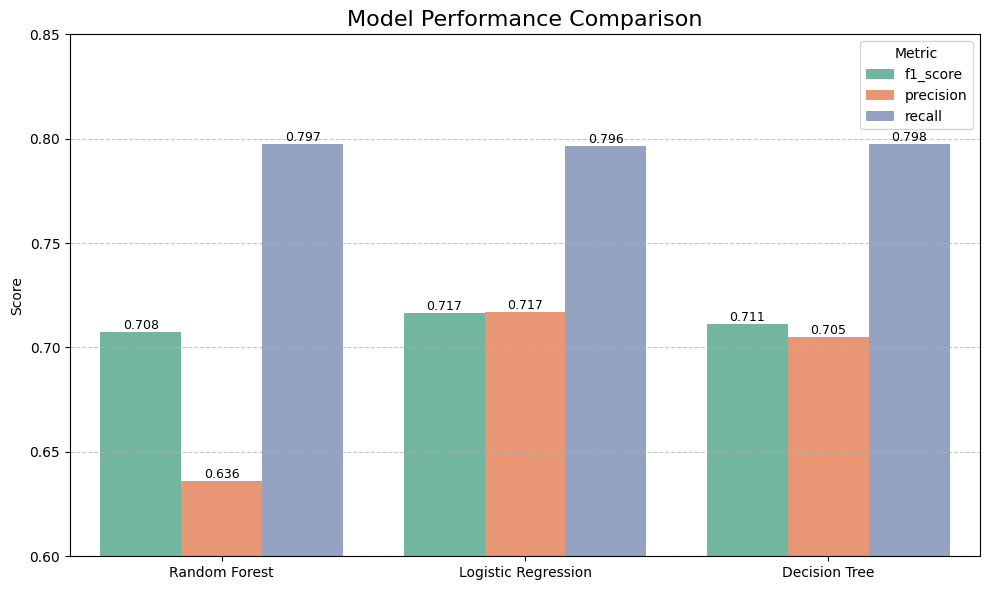

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
df_melted = df_melted[df_melted["Metric"] != "model"]
df_melted["Score"] = df_melted["Score"].astype(float)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=9)

plt.title("Model Performance Comparison", fontsize=16)
plt.ylim(0.6, 0.85)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


D’après tes résultats :
- F1-score le plus élevé : Logistic Regression (≈ 0.717)
- Bonne précision ET rappel

On garde la Logistic Regression pour la suite de l'etude 

## Model final

### Grid search

In [17]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

indexers = [StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep") for col in columns_to_encode]
encoders = [OneHotEncoder(inputCol=col + "_idx", outputCol=col + "_ohe") for col in columns_to_encode]

assembler_inputs = [col + "_ohe" for col in columns_to_encode] + numerical_features
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
label_indexer = StringIndexer(inputCol="Severity", outputCol="label", handleInvalid="skip")
lr = LogisticRegression(featuresCol="scaled_features", labelCol="label")

pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, label_indexer, lr])

In [18]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

paramGrid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1, 0.5])           # Regularization strength
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])     # ElasticNet mixing (0=L2, 1=L1)
    .addGrid(lr.maxIter, [50, 100])                   # Number of iterations
    .addGrid(lr.tol, [1e-6, 1e-4])                    # Convergence tolerance
    .build()
)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2,
)

In [19]:
cv_model = crossval.fit(train_sample)

In [20]:
best_model = cv_model.bestModel

In [ ]:
best_lr_model = best_model.stages[-1]

print("Meilleurs hyperparamètres :")
print(" - regParam:", best_lr_model._java_obj.getRegParam())
print(" - elasticNetParam:", best_lr_model._java_obj.getElasticNetParam())
print(" - maxIter:", best_lr_model._java_obj.getMaxIter())
print(" - tol:", best_lr_model._java_obj.getTol())

Meilleurs hyperparamètres :
 - regParam: 0.01
 - elasticNetParam: 0.0
 - maxIter: 50
 - tol: 0.0001


In [23]:
predictions = best_model.transform(test_sample)

In [25]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

f1_score = evaluator.evaluate(predictions)
precision_score = evaluator_precision.evaluate(predictions)
recall_score = evaluator_recall.evaluate(predictions)

print(f"F1 Score on test set: {f1_score:.3f}")
print(f"Precision Score on test set: {precision_score:.3f}")
print(f"Recall Score on test set: {recall_score:.3f}")

F1 Score on test set: 0.715
Precision Score on test set: 0.719
Recall Score on test set: 0.797


### Entrainement du modele final avec meilleurs hyperparametre sur le dataset entier

In [27]:
final_lr = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="label",
    regParam=0.01,
    elasticNetParam=0.0,
    maxIter=50,
    tol=0.0001
)

final_pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, label_indexer, final_lr])
final_model = final_pipeline.fit(train)

In [30]:
predictions = best_model.transform(test)

In [31]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

f1_score = evaluator.evaluate(predictions)
precision_score = evaluator_precision.evaluate(predictions)
recall_score = evaluator_recall.evaluate(predictions)

print(f"F1 Score on test set: {f1_score:.3f}")
print(f"Precision Score on test set: {precision_score:.3f}")
print(f"Recall Score on test set: {recall_score:.3f}")

F1 Score on test set: 0.713
Precision Score on test set: 0.712
Recall Score on test set: 0.796


In [32]:
final_model.write().overwrite().save("final_accident_model")

In [33]:
feur = final_model.stages[-1]
print(feur.numClasses)

4


In [34]:
spark.stop()